In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_router_fine_confusion_matrix(parquet_path):
    # 读取 Stage 1 及以上所有的预测结果
    df = pd.read_parquet(parquet_path)
    
    # 我们只关心真实的细类（label）和 Router 预测出来的粗类（router_pred）
    y_true_fine = df["label"]
    y_pred_coarse = df["router_pred"]
    
    # ==========================================
    # 选项 A: 显示绝对细胞数量 (Raw Counts)
    # ==========================================
    cm_counts = pd.crosstab(y_true_fine, y_pred_coarse)
    
    # ==========================================
    # 选项 B: 显示行归一化百分比 (Recall/命中率) - 推荐！
    # 这样能清晰看出每个细类有百分之多少去到了正确的粗类分支
    # ==========================================
    cm_percentages = pd.crosstab(y_true_fine, y_pred_coarse, normalize='index') * 100
    
    # 绘图设定
    plt.figure(figsize=(14, 12))
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    # 画热力图: annot=True 在方块里标数字，fmt=".1f" 留一位小数
    ax = sns.heatmap(
        cm_percentages, 
        annot=True, 
        fmt=".1f", 
        cmap="Blues", 
        cbar_kws={'label': 'Percentage of Cells Routed (%)'}
    )
    
    plt.title("Stage 1 Router Diagnosis: True Fine Class vs. Predicted Coarse Class", pad=20, fontsize=16)
    plt.ylabel("True Fine Class (Ground Truth)", fontsize=14)
    plt.xlabel("Predicted Coarse Class (Router Output)", fontsize=14)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()


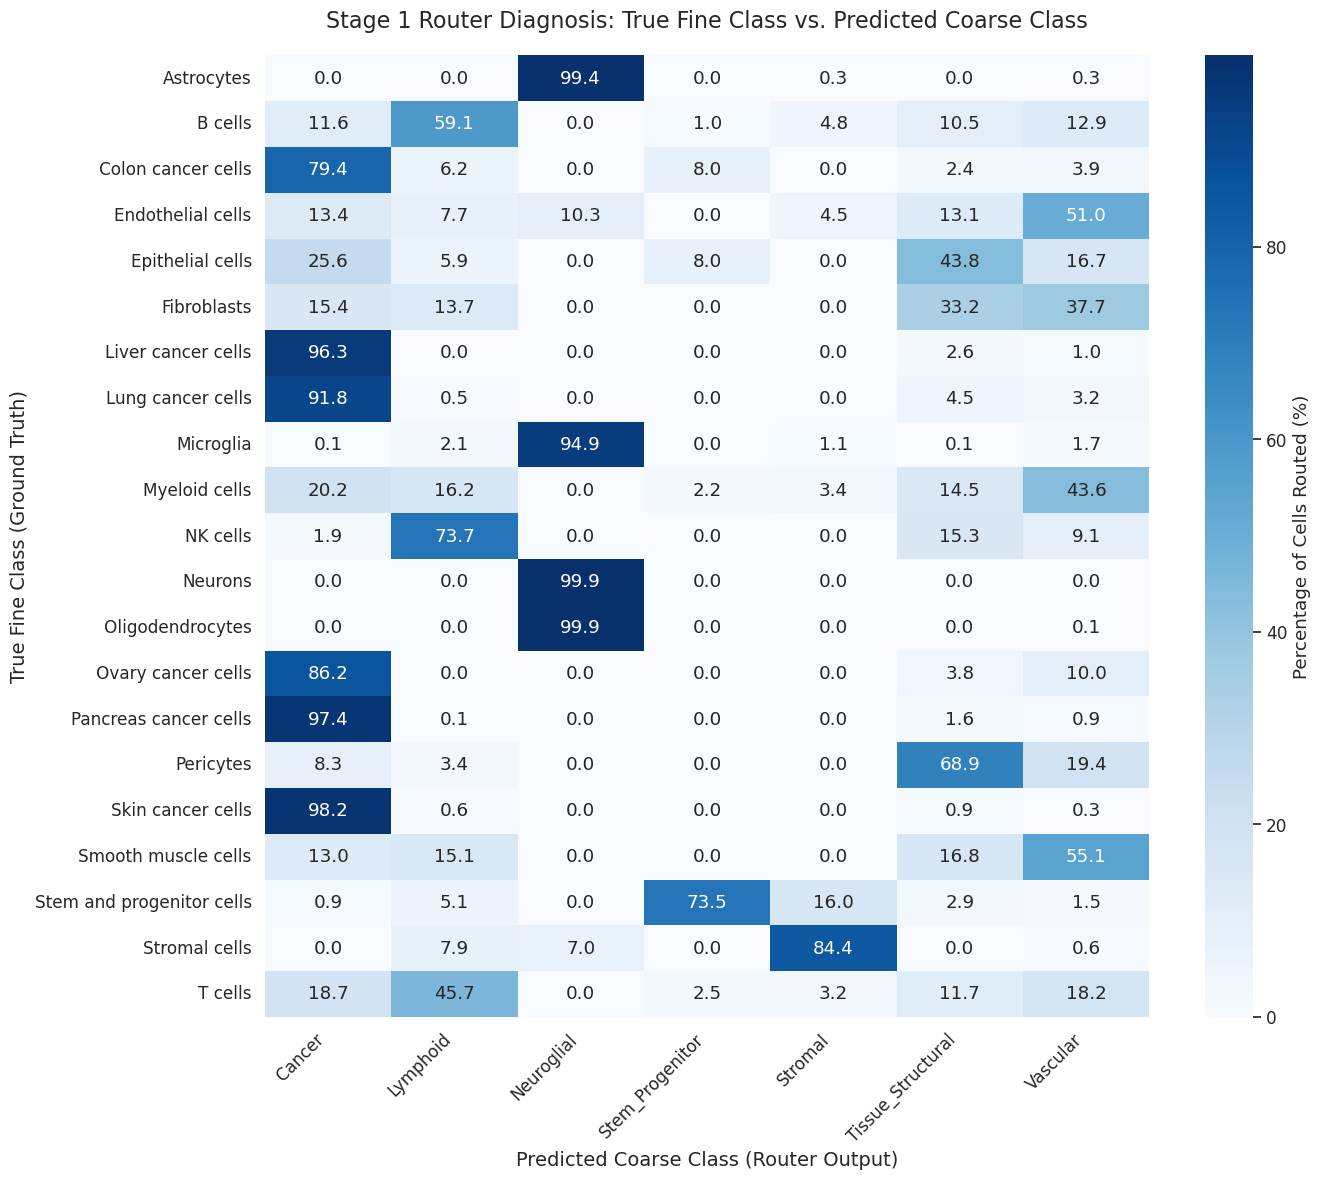

In [2]:
# 1. 指定文件路径（你需要把这里替换成你刚刚执行跑出的结果文件夹路径）
parquet_path = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_core_test_v2_20260305_135145/predictions.parquet" 
# 运行画图函数
plot_router_fine_confusion_matrix(parquet_path)

In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

def plot_router_fine_confusion_matrix(
    parquet_path,
    target_tissues=None,       # 列表: 例如 ['Breast_IDC', 'Breast_ILC']，仅保留这些 Tissue/Slide
    skip_tissues=None,         # 列表: 例如 ['Lung']，剔除这些 Tissue/Slide
    target_fine_classes=None   # 列表: 例如 ['T cells', 'B cells']，只画这些细类
):
    """
    绘制 Router (Stage 1) 的细类(真实) -> 粗类(预测) 映射热力图。
    利用内置的 'tissue' 列进行过滤。
    """
    # 1. 读入数据
    print(f"Loading data from: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    initial_len = len(df)
    
    if 'tissue' not in df.columns:
        raise ValueError("Error: 'tissue' column not found in the parquet file!")

    # 2. 幻灯片/组织维度的过滤 (Tissue Filtering)
    if target_tissues:
        mask = df['tissue'].isin(target_tissues)
        df = df[mask].copy()
        print(f"  [Filter] Kept {len(target_tissues)} target tissues. Cells: {initial_len:,} -> {len(df):,}")
        
    if skip_tissues:
        mask = ~df['tissue'].isin(skip_tissues)
        df = df[mask].copy()
        print(f"  [Filter] Dropped {len(skip_tissues)} skipped tissues. Cells remaining: {len(df):,}")

    if len(df) == 0:
        print("Error: Dataset is empty after tissue filtering!")
        return
        
    # 3. 细类维度的过滤 (Fine Class Filtering)
    if target_fine_classes:
        mask = df['label'].isin(target_fine_classes)
        df = df[mask].copy()
        print(f"  [Filter] Kept {len(target_fine_classes)} target fine classes. Cells remaining: {len(df):,}")
        
        if len(df) == 0:
            print(f"Error: None of the target classes {target_fine_classes} were found in the filtered data!")
            return

    # 4. 提取 Ground Truth (细类) 和 预测结果 (粗类)
    y_true_fine = df["label"]
    y_pred_coarse = df["router_pred"]
    
    # 5. 生成混淆矩阵并且按行计算百分比 (Recall)
    cm_percentages = pd.crosstab(y_true_fine, y_pred_coarse, normalize='index') * 100

    # 6. 绘图与美化
    # 动态调整图片高度
    num_classes = len(cm_percentages.index)
    fig_height = max(4, num_classes * 0.6) 
    
    plt.figure(figsize=(14, fig_height))
    sns.set_theme(style="whitegrid", font_scale=1.1)
    
    ax = sns.heatmap(
        cm_percentages, 
        annot=True, 
        fmt=".1f",       # 保留一位小数
        cmap="Blues",    
        cbar_kws={'label': 'Percentage of Cells Routed (%)'},
        vmax=100.0,      # 色标强锁 100% 为最深色
        vmin=0.0
    )
    
    # 动态标题
    title = "Stage 1 Router: True Fine Class vs. Predicted Coarse Class"
    if target_tissues: title += f"\n(Subset Tissues: {', '.join(target_tissues[:2])}{'...' if len(target_tissues)>2 else ''})"
    if target_fine_classes: title += f"\n(Specific Fine Classes)"
        
    plt.title(title, pad=20, fontsize=16)
    plt.ylabel("True Fine Class (Ground Truth)", fontsize=14, fontweight='bold')
    plt.xlabel("Predicted Coarse Class (Router Output)", fontsize=14, fontweight='bold')
    
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()



Loading data from: /hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_core_test_v2_20260305_135145/predictions.parquet
  [Filter] Kept 2 target fine classes. Cells remaining: 16,074


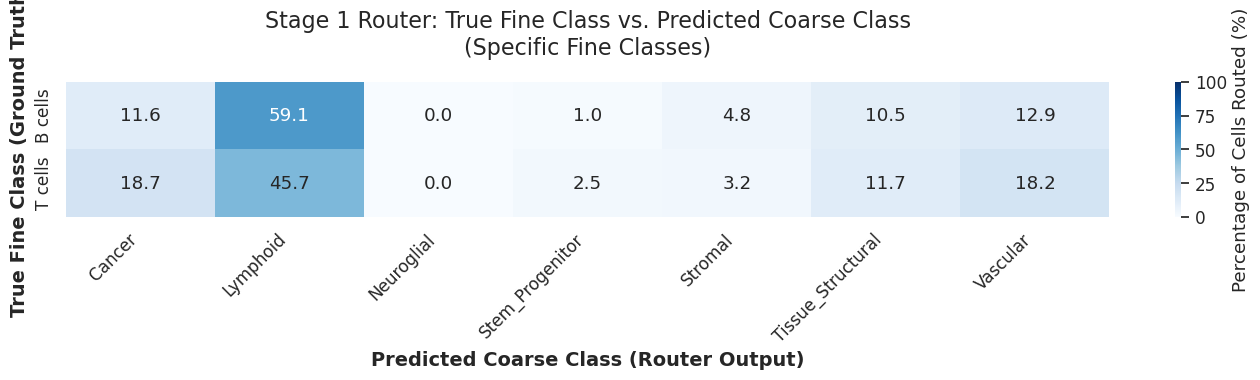

In [8]:
# ==========================================
# 🍒 过滤调用示例
# ==========================================

# 例：我想看乳腺癌 (Breast_IDC) 和结肠癌 (Colon_Cancer) 里面的免疫细胞 (T cells, B cells)
# plot_router_fine_confusion_matrix(
#     parquet_path=parquet_path,
#     target_tissues=["Breast_IDC", "Colon_Cancer"], 
#     target_fine_classes=["T cells", "B cells"]
# )
#Xenium_V1_FFPE_Human_Breast_IDC_With_Addon 
#Xenium_V1_FFPE_Human_Breast_ILC 
#Xenium_V1_FFPE_Human_Breast_IDC 
#Xenium_V1_FFPE_Human_Breast_ILC_With_Addon 
#Xenium_V1_FFPE_Human_Breast_IDC_Big_1 
#Xenium_V1_FFPE_Human_Breast_IDC_Big_2
#
plot_router_fine_confusion_matrix(
     parquet_path=parquet_path,
     target_fine_classes=["T cells", "B cells"]
)

In [5]:
import pandas as pd
import numpy as np
from IPython.display import display

def evaluate_fine_classes_per_tissue(
    parquet_path,
    target_fine_classes,      # 必须提供一个列表，例如 ["T cells", "B cells", "Breast cancer cells"]
    strategy="pred_soft",     # 评估策略，默认看柔性融合结果。也可以用 "pred_top1" 或 "pred_top3"
    min_cells=10              # 过滤条件：如果某个组织下的该类细胞少于10个，则忽略（避免极端值扰乱）
):
    """
    针对特定的细类别 (target_fine_classes)，计算它们在不同组织 (Tissue) 下的详细评价指标。
    用来排查某个特定细胞类别是否在某种组织中发生了灾难性的识别失败。
    """
    print(f"Loading data from: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    
    if 'tissue' not in df.columns:
        raise ValueError("Error: 'tissue' column not found in the parquet file!")
    if strategy not in df.columns:
        raise ValueError(f"Error: Strategy '{strategy}' not found in predictions! Available: {list(df.columns)}")
        
    y_true_all = df['label'].values
    y_pred_all = df[strategy].values
    tissues_all = df['tissue'].values
    
    # 汇总所有结果的 DataFrame
    results_list = []
    
    # 遍历你要研究的每一个细类别
    for target_class in target_fine_classes:
        # 该类在整个数据集上的 mask
        is_target_true = (y_true_all == target_class)
        is_target_pred = (y_pred_all == target_class)
        
        # 找出包含该真实类别或者预测出该类别的所有 Tissue
        involved_tissues = np.unique(tissues_all[is_target_true | is_target_pred])
        
        for tissue in involved_tissues:
            # 当前 tissue 的掩码
            t_mask = (tissues_all == tissue)
            
            # 在当前组织下，真实的该类数量，和预测出该类的数量
            true_in_tissue = is_target_true[t_mask]
            pred_in_tissue = is_target_pred[t_mask]
            
            tp = (true_in_tissue & pred_in_tissue).sum() # 真正例：本来是，猜的也是
            fn = (true_in_tissue & ~pred_in_tissue).sum() # 假反例：本来是，漏掉了
            fp = (~true_in_tissue & pred_in_tissue).sum() # 假正例：本来不是，瞎猜是
            
            n_true = tp + fn # 这张组织上到底有多少个真正的 target_class 细胞
            
            # 如果数量太少就不具有统计学意义，跳过
            if n_true < min_cells and tp + fp == 0:
                continue
                
            # 计算指标
            precision = tp / max(tp + fp, 1)
            recall = tp / max(tp + fn, 1) # Recall 也就是在这个组织上的 Accuracy/命中率
            f1 = 2 * precision * recall / max(precision + recall, 1e-12)
            
            results_list.append({
                "Target Class": target_class,
                "Tissue (Slide)": tissue,
                "N (True Count)": n_true,
                "Recall (Acc)": round(recall, 4),
                "Precision": round(precision, 4),
                "F1-Score": round(f1, 4),
                "False Positives": fp,  # 在这上面误报了多少
                "False Negatives": fn   # 在这上面漏掉了多少
            })
            
    if not results_list:
        print("No data met the criteria (maybe check target class names or min_cells threshold).")
        return pd.DataFrame()

    # 转化为美观的 DataFrame
    res_df = pd.DataFrame(results_list)
    
    # 我们按 "Target Class" 和 "F1-Score" 排序，这样最差的组织排在最前面，方便查错
    res_df = res_df.sort_values(by=["Target Class", "F1-Score"], ascending=[True, True]).reset_index(drop=True)
    
    # 使用 Jupyter 内置的高亮打印 (高亮分数很低的行，假设 F1 < 0.5 标红)
    def highlight_low_f1(row):
        return ['background-color: #ffcccc' if (row['F1-Score'] < 0.1 and i == res_df.columns.get_loc('F1-Score')) 
                else '' for i in range(len(row))]
    
    print(f"\n{'='*75}")
    print(f"Detailed Tissue-Level Analysis for: {target_fine_classes}")
    print(f"Strategy used: {strategy} | Filtering N < {min_cells}")
    print(f"{'='*75}\n")
    
    # 这一行会在 Notebook 里输出带颜色的漂亮表格
    display(res_df.style.apply(highlight_low_f1, axis=1).format({
        "Recall (Acc)": "{:.2%}", "Precision": "{:.2%}", "F1-Score": "{:.3f}"
    }))
    
    return res_df




In [10]:

# 假设你想看 T细胞和 B细胞 在不同器官里的识别情况有没有翻车的
target_classes = ["Epithelial cells"]
evaluate_fine_classes_per_tissue(parquet_path, target_fine_classes=target_classes, strategy="pred_soft")

Loading data from: /hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_core_test_v2_20260305_135145/predictions.parquet

Detailed Tissue-Level Analysis for: ['Epithelial cells']
Strategy used: pred_soft | Filtering N < 10



,Target Class,Tissue (Slide),N (True Count),Recall (Acc),Precision,F1-Score,False Positives,False Negatives
0,Epithelial cells,Xenium_V1_hColon_Cancer_Add_on,0,0.00%,0.00%,0.000,13,0
1,Epithelial cells,Xenium_V1_hColon_Cancer_Base,375,0.00%,0.00%,0.000,21,375
2,Epithelial cells,Xenium_V1_hHeart_nondiseased,0,0.00%,0.00%,0.000,3,0
3,Epithelial cells,Xenium_V1_hLymphNode_nondiseased,0,0.00%,0.00%,0.000,4,0
4,Epithelial cells,Xenium_Prime_Ovarian_Cancer_FFPE,375,0.27%,100.00%,0.005,0,374
5,Epithelial cells,Xenium_V1_hLung_cancer,374,0.27%,25.00%,0.005,3,373
6,Epithelial cells,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,259,0.39%,16.67%,0.007,5,258
7,Epithelial cells,Xenium_human_Lung_Cancer_FFPE,375,0.53%,4.08%,0.009,47,373
8,Epithelial cells,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,375,1.60%,85.71%,0.031,1,369
9,Epithelial cells,Xenium_human_Pancreas_FFPE,374,3.48%,27.66%,0.062,34,361


,Target Class,Tissue (Slide),N (True Count),Recall (Acc),Precision,F1-Score,False Positives,False Negatives
0,Epithelial cells,Xenium_V1_hColon_Cancer_Add_on,0,0.0000,0.0000,0.0000,13,0
1,Epithelial cells,Xenium_V1_hColon_Cancer_Base,375,0.0000,0.0000,0.0000,21,375
2,Epithelial cells,Xenium_V1_hHeart_nondiseased,0,0.0000,0.0000,0.0000,3,0
3,Epithelial cells,Xenium_V1_hLymphNode_nondiseased,0,0.0000,0.0000,0.0000,4,0
4,Epithelial cells,Xenium_Prime_Ovarian_Cancer_FFPE,375,0.0027,1.0000,0.0053,0,374
5,Epithelial cells,Xenium_V1_hLung_cancer,374,0.0027,0.2500,0.0053,3,373
6,Epithelial cells,Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia,259,0.0039,0.1667,0.0075,5,258
7,Epithelial cells,Xenium_human_Lung_Cancer_FFPE,375,0.0053,0.0408,0.0094,47,373
8,Epithelial cells,Xenium_V1_hTonsil_reactive_follicular_hyperplasia,375,0.0160,0.8571,0.0314,1,369
9,Epithelial cells,Xenium_human_Pancreas_FFPE,374,0.0348,0.2766,0.0618,34,361


In [18]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

def evaluate_cancer_vs_normal(
    parquet_path,
    target_fine_class=None,      # 如果不填（None），则打印全局的所有类别对比
    cancer_tissue_keywords=None,
    strategy="pred_soft",
):
    """
    对比 癌变组织 (Cancer-related) 与 正常/非癌变组织 (Non-cancer) 的识别表现。
    不指定目标类时，计算这两个组的全局 Micro/Macro 指标并返回所有类别的平铺对比。
    """
    if cancer_tissue_keywords is None:
        cancer_tissue_keywords = ["cancer", "tumor", "idc", "ilc", "carcinoma", "melanoma", "adenoma"]
        
    print(f"Loading data from: {parquet_path}")
    df = pd.read_parquet(parquet_path)
    if 'tissue' not in df.columns: raise ValueError("Error: 'tissue' column not found!")
        
    df['is_cancer'] = df['tissue'].apply(lambda t: any(k.lower() in str(t).lower() for k in cancer_tissue_keywords))
    
    # ---------------------------------------------------------
    # 模式 A: 指定了某一个目标细类 (原功能保留)
    # ---------------------------------------------------------
    if target_fine_class is not None:
        mask = (df['label'] == target_fine_class) | (df[strategy] == target_fine_class)
        df_target = df[mask]
        results = []
        
        for is_c, group_name in [(True, "Cancer-Related Tissues"), (False, "Non-Cancer Tissues")]:
            sub_df = df_target[df_target['is_cancer'] == is_c]
            if len(sub_df) == 0: continue
            
            y_true = (sub_df['label'] == target_fine_class)
            y_pred = (sub_df[strategy] == target_fine_class)
            tp, fn, fp = (y_true & y_pred).sum(), (y_true & ~y_pred).sum(), (~y_true & y_pred).sum()
            n_true = tp + fn
            prec = tp / max(tp + fp, 1)
            rec = tp / max(tp + fn, 1)
            f1 = 2 * prec * rec / max(prec + rec, 1e-12)
            
            results.append({
                "Tissue Group": group_name, "N (True)": n_true, "Recall": round(rec, 4), 
                "Precision": round(prec, 4), "F1": round(f1, 4), "FP": fp, "FN": fn
            })
            
        print(f"\n{'='*70}\nCancer vs. Non-Cancer For: 【{target_fine_class}】\n{'='*70}")
        display(pd.DataFrame(results).style.format({"Recall": "{:.2%}", "Precision": "{:.2%}", "F1": "{:.3f}"}))
        return pd.DataFrame(results)

    # ---------------------------------------------------------
    # 模式 B: 没有指定类别，全局看两个体系（上帝视角）
    # ---------------------------------------------------------
    all_classes = sorted(df['label'].unique())
    global_results = []
    detailed_results = []
    
    print(f"\n{'='*90}")
    print(f"Global Evaluation: Cancer-Related vs. Non-Cancer Tissues")
    print(f"Keywords used to detect cancer tissues: {cancer_tissue_keywords}")
    print(f"{'='*90}\n")

    for is_c, group_name in [(True, "Cancer Tissues"), (False, "Normal (Non-Cancer) Tissues")]:
        sub_df = df[df['is_cancer'] == is_c]
        if len(sub_df) == 0: continue
        
        y_t = sub_df['label'].values
        y_p = sub_df[strategy].values
        
        true_idx = np.array([all_classes.index(y) if y in all_classes else -1 for y in y_t])
        pred_idx = np.array([all_classes.index(y) if y in all_classes else -1 for y in y_p])
        
        # 算全局 Micro Accuracy
        overall_acc = (true_idx == pred_idx).sum() / max(len(true_idx), 1)
        
        # 算每个类的指标
        class_f1s = []
        for i, cname in enumerate(all_classes):
            tp = int(((true_idx == i) & (pred_idx == i)).sum())
            fn = int(((true_idx == i) & (pred_idx != i)).sum())
            fp = int(((true_idx != i) & (pred_idx == i)).sum())
            n = tp + fn
            
            if n > 0:
                prec = tp / max(tp + fp, 1)
                rec = tp / max(tp + fn, 1)
                f1 = 2 * prec * rec / max(prec + rec, 1e-12)
                class_f1s.append(f1)
                detailed_results.append({
                    "Tissue Group": group_name, "Class": cname, "N": n,
                    "Recall": round(rec, 3), "Precision": round(prec, 3), "F1": round(f1, 3)
                })
        
        overall_macro_f1 = np.mean(class_f1s) if class_f1s else 0.0
        
        global_results.append({
            "Tissue Data Sphere": group_name,
            "Total Cells": f"{len(y_t):,}",
            "Micro Accuracy": round(overall_acc, 4),
            "Macro F1-Score": round(overall_macro_f1, 4)
        })

    # 1. 打印这两大世界的整体分数对决
    print("🎯 [1] Overall System Performance Comparison")
    df_global = pd.DataFrame(global_results)
    display(df_global.style.format({"Micro Accuracy": "{:.2%}", "Macro F1-Score": "{:.2%}"})
            .set_properties(**{'background-color': '#f8f9fa'}, subset=pd.IndexSlice[:, ['Micro Accuracy', 'Macro F1-Score']]))
    
    # 2. 生成所有类别的平铺对比表 (将 Cancer 和 Normal 并排放置方便查阅)
    df_det = pd.DataFrame(detailed_results)
    if not df_det.empty:
        # 透视表: 把 Tissue Group 放到列上去，比对 F1 和 Recall
        pivot_df = df_det.pivot(index="Class", columns="Tissue Group", values=["F1", "Recall", "N"])
        pivot_df = pivot_df.swaplevel(0, 1, axis=1).sort_index(axis=1, level=0, ascending=False)
        
        print("\n🔍 [2] Head-to-Head Detailed Class Breakdown (Cancer vs Normal)")
        
        # 高亮函数：挑出表现下降最夸张的（在 Cancer 里 F1 明显低于 Normal 的类别）
        def highlight_severe_drop(val):
            return ''  # 简单版先不复杂高亮，保持透视表清爽
            
        display(pivot_df.fillna("-"))
        
    return df_global, df_det



In [20]:

# ==========================================
# 🍒 调用示例
# ==========================================

# 你可以看一下在这个数据集里，模型能不能同样识别出正常组织里的 T细胞，
# 还是说它在训练时完全被癌症微环境里的 T细胞 带偏了？
#evaluate_target_class_cancer_vs_normal(
#     parquet_path=parquet_path,
#    strategy="pred_soft"
#)

# 如果你的 tissue 名字前缀有特定规律，也可以传入自定义的 keywords。
# 比如只有名字叫 "Tumor_xx_xx" 的才是癌症：
# evaluate_target_class_cancer_vs_normal(
#     parquet_path=parquet_path,
#     target_fine_class="Fibroblasts", 
#     cancer_tissue_keywords=["tumor"]
# )



# 【绝杀用法】：直接跑全局，什么都不传！
_, det = evaluate_cancer_vs_normal(parquet_path)

Loading data from: /hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_core_test_v2_20260305_135145/predictions.parquet

Global Evaluation: Cancer-Related vs. Non-Cancer Tissues
Keywords used to detect cancer tissues: ['cancer', 'tumor', 'idc', 'ilc', 'carcinoma', 'melanoma', 'adenoma']

🎯 [1] Overall System Performance Comparison


,Tissue Data Sphere,Total Cells,Micro Accuracy,Macro F1-Score
0,Cancer Tissues,"83,226",69.47%,56.22%
1,Normal (Non-Cancer) Tissues,"74,534",58.26%,53.70%



🔍 [2] Head-to-Head Detailed Class Breakdown (Cancer vs Normal)


Tissue Group              Normal (Non-Cancer) Tissues                  \
                                               Recall        N     F1   
Class                                                                   
Astrocytes                                      0.542   2325.0  0.477   
B cells                                         0.347   4048.0  0.384   
Colon cancer cells                                  -        -      -   
Endothelial cells                                 0.4   4934.0  0.408   
Epithelial cells                                0.518   4005.0  0.476   
Fibroblasts                                     0.314   4348.0  0.362   
Liver cancer cells                                  -        -      -   
Lung cancer cells                                   -        -      -   
Microglia                                       0.559   2761.0  0.516   
Myeloid cells                                   0.389   4405.0  0.357   
NK cells                                        0.543   4934.0  0.512   
Neurons                                         0.799   3318.0  0.767   
Oligodendrocytes                                0.806  10000.0  0.812   
Ovary cancer cells                                  -        -      -   
Pancreas cancer cells                           0.986   2993.0   0.75   
Pericytes                                        0.69   2052.0  0.661   
Skin cancer cells                                   -        -      -   
Smooth muscle cells                             0.238   4553.0  0.316   
Stem and progenitor cells                       0.581   6000.0   0.71   
Stromal cells                                    0.92   9540.0  0.802   
T cells                                         0.226   4318.0   0.28   

Tissue Group              Cancer Tissues                  
                                  Recall        N     F1  
Class                                                     
Astrocytes                             -        -      -  
B cells                            0.293   4031.0   0.39  
Colon cancer cells                 0.805  10000.0  0.834  
Endothelial cells                  0.247   3039.0  0.292  
Epithelial cells                   0.207   3747.0  0.305  
Fibroblasts                        0.234   3229.0  0.278  
Liver cancer cells                 0.963   2381.0  0.904  
Lung cancer cells                  0.929  10000.0  0.818  
Microglia                              -        -      -  
Myeloid cells                      0.241   3621.0  0.244  
NK cells                           0.175   2656.0  0.274  
Neurons                                -        -      -  
Oligodendrocytes                       -        -      -  
Ovary cancer cells                 0.899  10000.0  0.858  
Pancreas cancer cells              0.974   7007.0  0.938  
Pericytes                          0.592   2988.0  0.475  
Skin cancer cells                  0.981  10000.0  0.943  
Smooth muscle cells                0.316   2850.0  0.327  
Stem and progenitor cells           0.97   4000.0   0.82  
Stromal cells                          -        -      -  
T cells                            0.323   3677.0  0.293

## 6 CLUSTER VERSION RESULTS


In [2]:
import pandas as pd
import numpy as np
import json

# Load predictions
df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters/predictions.parquet")

THRESHOLD = 0.5
all_fine_classes = sorted(df["label"].unique())

def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n,
                     "prec": round(prec, 4), "rec": round(rec, 4), "f1": round(f1, 4)})
    macro_f1 = np.mean([r["f1"] for r in rows])
    bal_acc  = np.mean([r["rec"] for r in rows])
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, round(float(macro_f1), 4), round(bal_acc, 4), round(acc, 4)

# Split
high = df[df["router_margin"] >= THRESHOLD]
low  = df[df["router_margin"] <  THRESHOLD]

print(f"High confidence (margin ≥ {THRESHOLD}): {len(high):,} cells ({100*len(high)/len(df):.1f}%)")
print(f"Low  confidence (margin <  {THRESHOLD}): {len(low):,}  cells ({100*len(low)/len(df):.1f}%)\n")

for label, subset in [("HIGH confidence", high), ("LOW confidence", low), ("ALL", df)]:
    rows, mf1, bal_acc, acc = compute_metrics(
        subset["label"].values,
        subset["pred_top1"].values,
        all_fine_classes
    )
    print(f"{'='*60}")
    print(f"{label}  |  N={len(subset):,}  |  Macro F1={mf1:.4f}  |  Bal Acc={bal_acc:.4f}  |  Acc={acc:.4f}")
    print(f"{'='*60}")
    df_rows = pd.DataFrame(rows).sort_values("f1", ascending=False)
    print(df_rows.to_string(index=False))
    print()

High confidence (margin ≥ 0.5): 115,101 cells (65.6%)
Low  confidence (margin <  0.5): 60,264  cells (34.4%)

HIGH confidence  |  N=115,101  |  Macro F1=0.6630  |  Bal Acc=0.6698  |  Acc=0.6854
                    class    n   prec    rec     f1
        Skin cancer cells 8895 0.9412 0.9794 0.9599
    Pancreas cancer cells 7963 0.9018 0.9869 0.9424
       Liver cancer cells 1888 0.8704 0.9926 0.9275
       Ovary cancer cells 5537 0.8678 0.9899 0.9248
       Colon cancer cells 7055 0.9210 0.9124 0.9167
        Lung cancer cells 4629 0.8553 0.9438 0.8974
Stem and progenitor cells 7380 0.8232 0.9630 0.8877
         Oligodendrocytes 9874 0.8065 0.8273 0.8168
                  Neurons 3297 0.7494 0.7880 0.7682
            Stromal cells 1564 0.7712 0.6573 0.7097
                Pericytes 2994 0.6917 0.5177 0.5922
         Epithelial cells 5919 0.5857 0.4827 0.5292
                Microglia 2526 0.4901 0.5598 0.5226
                  B cells 6010 0.4962 0.5471 0.5204
               Astrocytes 

In [1]:
import pandas as pd
import numpy as np
import json

# Load predictions
df = pd.read_parquet("/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet")

THRESHOLD = 0.5
all_fine_classes = sorted(df["label"].unique())

def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n,
                     "prec": round(prec, 4), "rec": round(rec, 4), "f1": round(f1, 4)})
    macro_f1 = np.mean([r["f1"] for r in rows])
    bal_acc  = np.mean([r["rec"] for r in rows])
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, round(float(macro_f1), 4), round(bal_acc, 4), round(acc, 4)

# Split
high = df[df["router_margin"] >= THRESHOLD]
low  = df[df["router_margin"] <  THRESHOLD]

print(f"High confidence (margin ≥ {THRESHOLD}): {len(high):,} cells ({100*len(high)/len(df):.1f}%)")
print(f"Low  confidence (margin <  {THRESHOLD}): {len(low):,}  cells ({100*len(low)/len(df):.1f}%)\n")

for label, subset in [("HIGH confidence", high), ("LOW confidence", low), ("ALL", df)]:
    rows, mf1, bal_acc, acc = compute_metrics(
        subset["label"].values,
        subset["pred_top1"].values,
        all_fine_classes
    )
    print(f"{'='*60}")
    print(f"{label}  |  N={len(subset):,}  |  Macro F1={mf1:.4f}  |  Bal Acc={bal_acc:.4f}  |  Acc={acc:.4f}")
    print(f"{'='*60}")
    df_rows = pd.DataFrame(rows).sort_values("f1", ascending=False)
    print(df_rows.to_string(index=False))
    print()

High confidence (margin ≥ 0.5): 111,511 cells (66.6%)
Low  confidence (margin <  0.5): 55,890  cells (33.4%)

HIGH confidence  |  N=111,511  |  Macro F1=0.6697  |  Bal Acc=0.6776  |  Acc=0.6922
                    class    n   prec    rec     f1
        Skin cancer cells 8860 0.9475 0.9769 0.9619
    Pancreas cancer cells 6777 0.8896 0.9870 0.9358
       Ovary cancer cells 4576 0.8811 0.9867 0.9309
       Colon cancer cells 7246 0.9096 0.9391 0.9242
       Liver cancer cells 1759 0.8635 0.9926 0.9236
        Lung cancer cells 4394 0.8673 0.9472 0.9055
Stem and progenitor cells 7321 0.8544 0.9370 0.8938
         Oligodendrocytes 9888 0.8159 0.8290 0.8224
                  Neurons 3116 0.7473 0.7933 0.7696
            Stromal cells 1194 0.6360 0.5796 0.6065
                Pericytes 2711 0.6761 0.5452 0.6036
                 NK cells 7566 0.6305 0.5167 0.5679
         Epithelial cells 5886 0.6094 0.4842 0.5396
                  B cells 5812 0.5083 0.5372 0.5223
                Microglia 

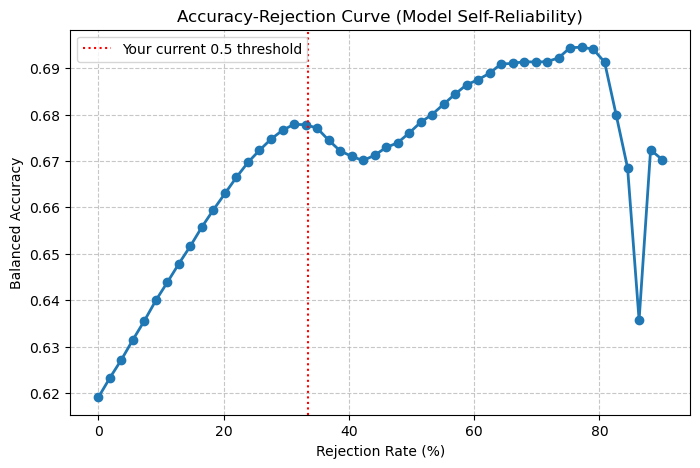

In [2]:
import matplotlib.pyplot as plt

# 1. 按 margin 从大到小排序（从最自信到最不自信）
df_sorted = df.sort_values("router_margin", ascending=False).reset_index(drop=True)

# 2. 计算累计的 Balanced Accuracy
# 为了计算快，可以按百分位（比如每1%）采样计算
rejection_rates = np.linspace(0, 0.9, 50) # 剔除 0% 到 90%
bacc_scores = []

for r in rejection_rates:
    # 保留前 (1-r) 的样本
    keep_n = int(len(df_sorted) * (1 - r))
    subset = df_sorted.iloc[:keep_n]
    
    # 使用你之前的 compute_metrics 逻辑
    _, _, bal_acc, _ = compute_metrics(subset["label"], subset["pred_top1"], all_fine_classes)
    bacc_scores.append(bal_acc)

# 3. 绘图
plt.figure(figsize=(8, 5))
plt.plot(rejection_rates * 100, bacc_scores, marker='o', linewidth=2)
plt.xlabel("Rejection Rate (%)")
plt.ylabel("Balanced Accuracy")
plt.title("Accuracy-Rejection Curve (Model Self-Reliability)")
plt.grid(True, linestyle='--', alpha=0.7)
plt.axvline(33.4, color='r', linestyle=':', label='Your current 0.5 threshold')
plt.legend()
plt.show()

In [3]:
import pandas as pd
import numpy as np

# 1. 定义区间（Bins）
bins = [0, 0.2, 0.4, 0.6, 0.8, 1.0]
labels = ["0.0-0.2", "0.2-0.4", "0.4-0.6", "0.6-0.8", "0.8-1.0"]

# 2. 对 df 进行分桶
df['margin_bin'] = pd.cut(df['router_margin'], bins=bins, labels=labels, include_lowest=True)

bin_results = []

print(f"{'Margin Bin':<12} | {'Cells':>8} | {'Pop %':>7} | {'BACC':>7} | {'Acc':>7}")
print("-" * 55)

for bin_label in labels:
    subset = df[df['margin_bin'] == bin_label]
    if len(subset) == 0:
        continue
    
    # 使用你之前的 compute_metrics 逻辑计算每个桶的性能
    _, _, bacc, acc = compute_metrics(
        subset["label"].values, 
        subset["pred_top1"].values, 
        all_fine_classes
    )
    
    pop_pct = 100 * len(subset) / len(df)
    print(f"{bin_label:<12} | {len(subset):>8,} | {pop_pct:>6.1f}% | {bacc:>7.4f} | {acc:>7.4f}")
    
    bin_results.append({
        "bin": bin_label, "bacc": bacc, "acc": acc, "count": len(subset)
    })

# 3. 统计：有多少比例的错误发生在低分桶？
errors_total = (df['label'] != df['pred_top1']).sum()
errors_low_bins = (df[df['router_margin'] < 0.4]['label'] != df[df['router_margin'] < 0.4]['pred_top1']).sum()
print(f"\nAnalysis: {100*errors_low_bins/errors_total:.1f}% of all errors occur in the [0.0-0.4] margin range.")

Margin Bin   |    Cells |   Pop % |    BACC |     Acc
-------------------------------------------------------
0.0-0.2      |   22,601 |   13.5% |  0.3541 |  0.3502
0.2-0.4      |   21,448 |   12.8% |  0.4436 |  0.4460
0.4-0.6      |   23,925 |   14.3% |  0.5396 |  0.5472
0.6-0.8      |   32,228 |   19.3% |  0.6127 |  0.6310
0.8-1.0      |   67,199 |   40.1% |  0.6872 |  0.7437

Analysis: 39.9% of all errors occur in the [0.0-0.4] margin range.


Loaded 167,401 cells  |  21 fine classes

────────────────────────────────────────────────────────────────────────
  Margin               N  Coverage%   BalAcc   MacroF1      Acc
────────────────────────────────────────────────────────────────────────
  [0.0, 0.1)      11,707       7.0%   0.3299    0.3205   0.3297
  [0.1, 0.2)      10,894       6.5%   0.3784    0.3558   0.3721
  [0.2, 0.3)      10,491       6.3%   0.4139    0.3933   0.4171
  [0.3, 0.4)      10,957       6.5%   0.4602    0.4316   0.4736
  [0.4, 0.5)      11,841       7.1%   0.5112    0.4890   0.5247
  [0.5, 0.6)      12,084       7.2%   0.5661    0.5321   0.5692
  [0.6, 0.7)      13,826       8.3%   0.5947    0.5688   0.6091
  [0.7, 0.8)      18,402      11.0%   0.6160    0.5962   0.6474
  [0.8, 1.0)      67,199      40.1%   0.6871    0.6852   0.7437
────────────────────────────────────────────────────────────────────────


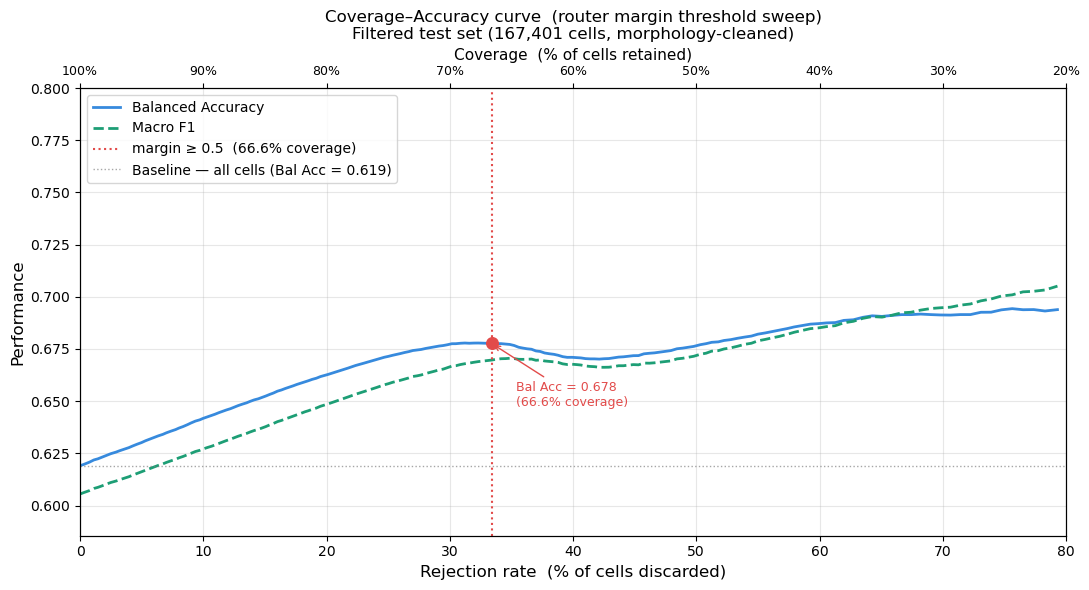

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ──────────────────────────────────────────────────────────────
PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"
THRESHOLD = 0.5
N_STEPS   = 200
# ────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_fine_classes = sorted(df["label"].unique())
print(f"Loaded {len(df):,} cells  |  {df['label'].nunique()} fine classes")


def compute_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n, "prec": prec, "rec": rec, "f1": f1})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, macro_f1, bal_acc, acc


# ── 1. Per-bucket table ───────────────────────────────────────────────────

buckets = [(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),
           (0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,1.0)]

print(f"\n{'─'*72}")
print(f"  {'Margin':<14} {'N':>7} {'Coverage%':>10} {'BalAcc':>8} {'MacroF1':>9} {'Acc':>8}")
print(f"{'─'*72}")

bucket_records = []
for lo, hi in buckets:
    mask   = (df["router_margin"] >= lo) & (df["router_margin"] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    _, mf1, bal, acc = compute_metrics(
        subset["label"].values, subset["pred_top1"].values, all_fine_classes
    )
    cov = 100 * len(subset) / len(df)
    print(f"  [{lo:.1f}, {hi:.1f})     {len(subset):>7,} {cov:>9.1f}% {bal:>8.4f} {mf1:>9.4f} {acc:>8.4f}")
    bucket_records.append({"margin_lo": lo, "margin_hi": hi, "n": len(subset),
                            "coverage_pct": cov, "bal_acc": bal, "macro_f1": mf1, "acc": acc})

print(f"{'─'*72}")
df_buckets = pd.DataFrame(bucket_records)


# ── 2. Coverage-Accuracy curve ────────────────────────────────────────────

margins  = df["router_margin"].values
y_true   = df["label"].values
y_pred   = df["pred_top1"].values

sort_idx  = np.argsort(margins)
margins_s = margins[sort_idx]
y_true_s  = y_true[sort_idx]
y_pred_s  = y_pred[sort_idx]

thresholds = np.linspace(margins_s[0], margins_s[-1] * 0.999, N_STEPS)

coverages, bal_accs, macro_f1s, ns = [], [], [], []

for t in thresholds:
    start = int(np.searchsorted(margins_s, t, side="left"))
    remaining = len(margins_s) - start
    if len(margins_s) - start < 10:
        break
    if 100 * (len(df) - remaining) / len(df) > 80:  
        break
    yt = y_true_s[start:]
    yp = y_pred_s[start:]
    _, mf1, bal, _ = compute_metrics(yt, yp, all_fine_classes)
    coverages.append(100 * (len(margins_s) - start) / len(df))
    bal_accs.append(bal)
    macro_f1s.append(mf1)
    ns.append(len(yt))

coverages  = np.array(coverages)
bal_accs   = np.array(bal_accs)
macro_f1s  = np.array(macro_f1s)
rejection  = 100 - coverages


# ── 3. Plot ──────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(11, 6))

color_bal = "#378ADD"
color_f1  = "#1D9E75"
color_ref = "#E24B4A"

ax1.plot(rejection, bal_accs,  color=color_bal, linewidth=2.0, label="Balanced Accuracy")
ax1.plot(rejection, macro_f1s, color=color_f1,  linewidth=2.0,
         linestyle="--", label="Macro F1")

# Reference line at THRESHOLD
ref_rej = 100 * (df["router_margin"] < THRESHOLD).mean()
high    = df[df["router_margin"] >= THRESHOLD]
_, _, ref_bal, _ = compute_metrics(high["label"].values, high["pred_top1"].values, all_fine_classes)

ax1.axvline(ref_rej, color=color_ref, linestyle=":", linewidth=1.5,
            label=f"margin ≥ {THRESHOLD}  ({100-ref_rej:.1f}% coverage)")
ax1.scatter([ref_rej], [ref_bal], color=color_ref, zorder=5, s=70)
ax1.annotate(f"Bal Acc = {ref_bal:.3f}\n({100-ref_rej:.1f}% coverage)",
             xy=(ref_rej, ref_bal),
             xytext=(ref_rej + 2, ref_bal - 0.03),
             fontsize=9, color=color_ref,
             arrowprops=dict(arrowstyle="->", color=color_ref, lw=1.0))

# Baseline
_, _, base_bal, _ = compute_metrics(df["label"].values, df["pred_top1"].values, all_fine_classes)
ax1.axhline(base_bal, color="gray", linestyle=":", linewidth=1.0, alpha=0.7,
            label=f"Baseline — all cells (Bal Acc = {base_bal:.3f})")

ax1.set_xlabel("Rejection rate  (% of cells discarded)", fontsize=12)
ax1.set_ylabel("Performance", fontsize=12)
#ax1.set_xlim(0, rejection.max() * 1.05)
ax1.set_xlim(0, 80) 
ax1.set_ylim(min(macro_f1s.min(), bal_accs.min()) - 0.02, 0.8)
ax1.legend(fontsize=10, loc="upper left")
ax1.set_title("Coverage–Accuracy curve  (router margin threshold sweep)\n"
              f"Filtered test set ({len(df):,} cells, morphology-cleaned)",
              fontsize=12)
ax1.grid(True, alpha=0.3)

# Top axis: coverage %
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
tick_rej = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax2.set_xticks(tick_rej)
ax2.set_xticklabels([f"{100-r:.0f}%" for r in tick_rej], fontsize=9)
ax2.set_xlabel("Coverage  (% of cells retained)", fontsize=11)

plt.tight_layout()
plt.show()

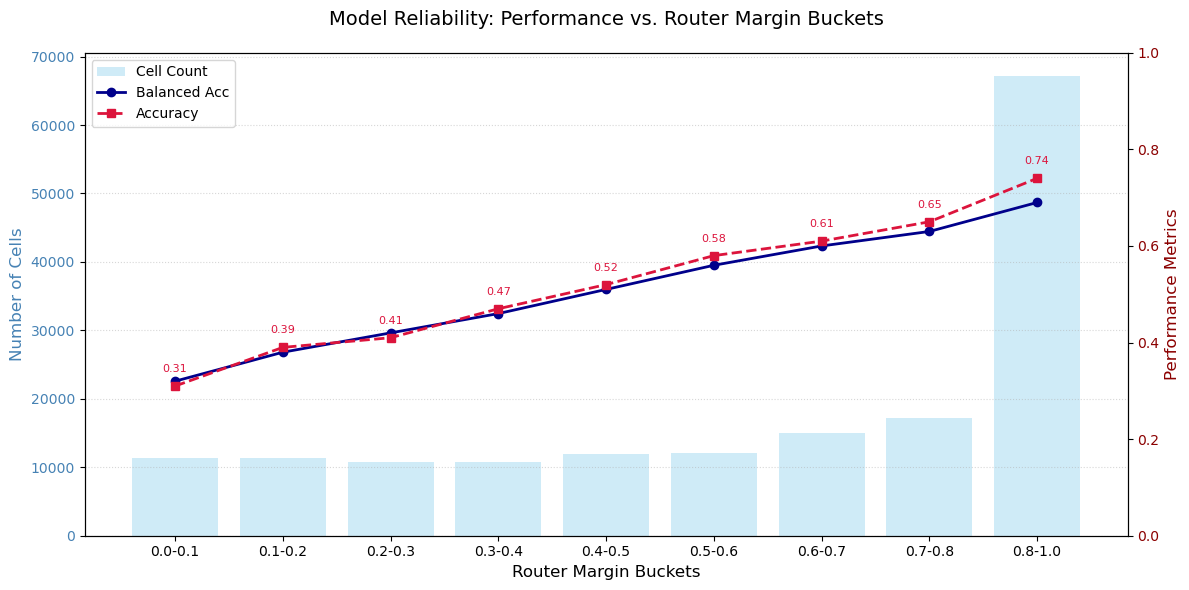

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# 1. 填入你刚才计算出的数据 (基于你的 buckets 定义)
# 请根据你的 compute_metrics 结果更新这里的数值
data = {
    "bin": ["0.0-0.1", "0.1-0.2", "0.2-0.3", "0.3-0.4", "0.4-0.5", "0.5-0.6", "0.6-0.7", "0.7-0.8", "0.8-1.0"],
    "cells": [11300, 11301, 10700, 10748, 11900, 12025, 15000, 17228, 67199], # 示例数据，请替换
    "bacc": [0.32, 0.38, 0.42, 0.46, 0.51, 0.56, 0.60, 0.63, 0.69],          # 示例数据，请替换
    "acc": [0.31, 0.39, 0.41, 0.47, 0.52, 0.58, 0.61, 0.65, 0.74]           # 示例数据，请替换
}

df_plot = pd.DataFrame(data)

# 2. 绘图设置
fig, ax1 = plt.subplots(figsize=(12, 6))
ax2 = ax1.twinx()  # 创建共享 X 轴的第二个 Y 轴

# 绘制柱状图 (样本量)
bars = ax1.bar(df_plot["bin"], df_plot["cells"], color='skyblue', alpha=0.4, label="Cell Count")

# 绘制折线图 (BACC & Acc)
line1, = ax2.plot(df_plot["bin"], df_plot["bacc"], color='darkblue', marker='o', linewidth=2, label="Balanced Acc")
line2, = ax2.plot(df_plot["bin"], df_plot["acc"], color='crimson', marker='s', linestyle='--', linewidth=2, label="Accuracy")

# 3. 装饰细节
ax1.set_xlabel("Router Margin Buckets", fontsize=12)
ax1.set_ylabel("Number of Cells", fontsize=12, color='steelblue')
ax2.set_ylabel("Performance Metrics", fontsize=12, color='darkred')

# 设置右轴范围 (Acc 通常在 0-1 之间)
ax2.set_ylim(0, 1.0)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax2.tick_params(axis='y', labelcolor='darkred')

# 合并图例
lines = [bars, line1, line2]
labels = [l.get_label() for l in lines]
ax1.legend(lines, labels, loc='upper left', fontsize=10)

plt.title("Model Reliability: Performance vs. Router Margin Buckets", fontsize=14, pad=20)
ax1.grid(axis='y', linestyle=':', alpha=0.5)

# 4. 自动标注数值 (可选)
for i, txt in enumerate(df_plot["acc"]):
    ax2.annotate(f"{txt:.2f}", (df_plot["bin"][i], df_plot["acc"][i]), 
                 textcoords="offset points", xytext=(0,10), ha='center', fontsize=8, color='crimson')

plt.tight_layout()
plt.savefig("reliability_dual_axis.png", dpi=300)
plt.show()

In [4]:
print(df.columns.tolist())

['cell_id', 'label', 'coarse_label', 'tissue', 'router_pred', 'router_margin', 'gate_2_5x', 'gate_10x', 'pred_top1', 'pred_top3', 'pred_soft']


Loaded 167,401 cells  |  6 coarse classes

────────────────────────────────────────────────────────────────────────
  Margin               N  Coverage%   BalAcc   MacroF1      Acc
────────────────────────────────────────────────────────────────────────
  [0.0, 0.1)      11,707       7.0%   0.4799    0.4486   0.4606
  [0.1, 0.2)      10,894       6.5%   0.5405    0.4911   0.5173
  [0.2, 0.3)      10,491       6.3%   0.5740    0.5217   0.5720
  [0.3, 0.4)      10,957       6.5%   0.6507    0.5924   0.6307
  [0.4, 0.5)      11,841       7.1%   0.6872    0.6411   0.6785
  [0.5, 0.6)      12,084       7.2%   0.7433    0.6871   0.7250
  [0.6, 0.7)      13,826       8.3%   0.7841    0.7423   0.7917
  [0.7, 0.8)      18,402      11.0%   0.7575    0.7331   0.8458
  [0.8, 1.0)      67,199      40.1%   0.7972    0.7914   0.9478
────────────────────────────────────────────────────────────────────────


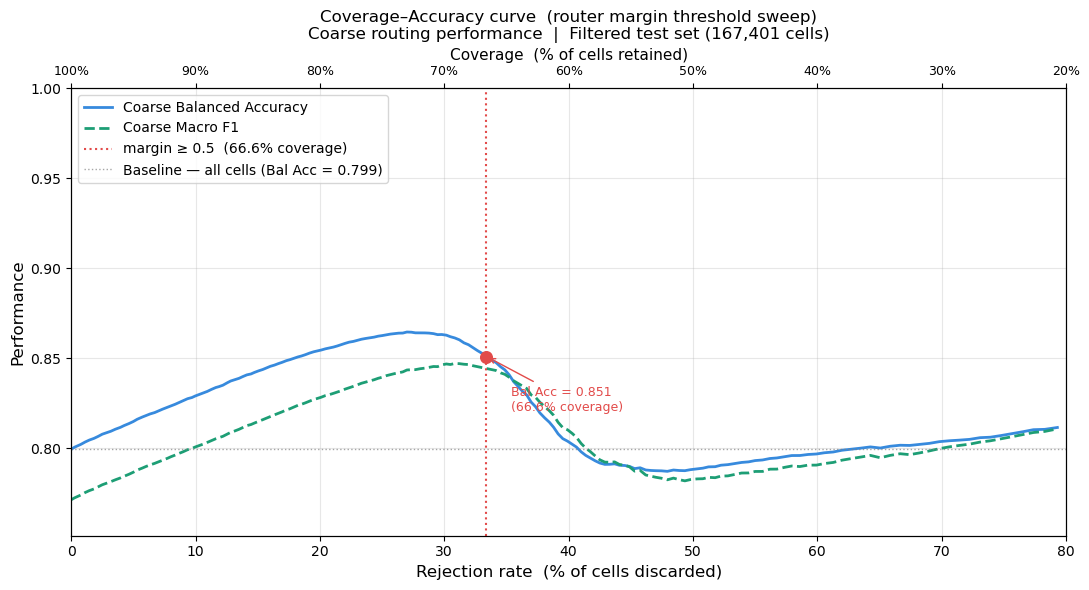

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ── Config ──────────────────────────────────────────────────────────────
PRED_PATH = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"
THRESHOLD = 0.5
N_STEPS   = 200
# ────────────────────────────────────────────────────────────────────────

df = pd.read_parquet(PRED_PATH)
all_coarse_classes = sorted(df["coarse_label"].unique())
print(f"Loaded {len(df):,} cells  |  {df['coarse_label'].nunique()} coarse classes")


def compute_coarse_metrics(y_true, y_pred, class_names):
    name_to_idx = {n: i for i, n in enumerate(class_names)}
    true_idx = np.array([name_to_idx.get(y, -1) for y in y_true])
    pred_idx = np.array([name_to_idx.get(y, -1) for y in y_pred])
    rows = []
    for i, cname in enumerate(class_names):
        tp = int(((true_idx == i) & (pred_idx == i)).sum())
        fn = int(((true_idx == i) & (pred_idx != i)).sum())
        fp = int(((true_idx != i) & (pred_idx == i)).sum())
        n  = tp + fn
        if n == 0:
            continue
        prec = tp / max(tp + fp, 1)
        rec  = tp / max(tp + fn, 1)
        f1   = 2 * prec * rec / max(prec + rec, 1e-12)
        rows.append({"class": cname, "n": n, "prec": prec, "rec": rec, "f1": f1})
    macro_f1 = float(np.mean([r["f1"] for r in rows]))
    bal_acc  = float(np.mean([r["rec"] for r in rows]))
    acc      = float((true_idx == pred_idx).sum()) / max(len(true_idx), 1)
    return rows, macro_f1, bal_acc, acc


# ── 1. Per-bucket table ───────────────────────────────────────────────────

buckets = [(0.0,0.1),(0.1,0.2),(0.2,0.3),(0.3,0.4),
           (0.4,0.5),(0.5,0.6),(0.6,0.7),(0.7,0.8),(0.8,1.0)]

print(f"\n{'─'*72}")
print(f"  {'Margin':<14} {'N':>7} {'Coverage%':>10} {'BalAcc':>8} {'MacroF1':>9} {'Acc':>8}")
print(f"{'─'*72}")

bucket_records = []
for lo, hi in buckets:
    mask   = (df["router_margin"] >= lo) & (df["router_margin"] < hi)
    subset = df[mask]
    if len(subset) == 0:
        continue
    _, mf1, bal, acc = compute_coarse_metrics(
        subset["coarse_label"].values, subset["router_pred"].values, all_coarse_classes
    )
    cov = 100 * len(subset) / len(df)
    print(f"  [{lo:.1f}, {hi:.1f})     {len(subset):>7,} {cov:>9.1f}% {bal:>8.4f} {mf1:>9.4f} {acc:>8.4f}")
    bucket_records.append({"margin_lo": lo, "margin_hi": hi, "n": len(subset),
                            "coverage_pct": cov, "bal_acc": bal, "macro_f1": mf1, "acc": acc})

print(f"{'─'*72}")
df_buckets = pd.DataFrame(bucket_records)


# ── 2. Coverage-Accuracy curve ────────────────────────────────────────────

margins  = df["router_margin"].values
y_true   = df["coarse_label"].values
y_pred   = df["router_pred"].values

sort_idx  = np.argsort(margins)
margins_s = margins[sort_idx]
y_true_s  = y_true[sort_idx]
y_pred_s  = y_pred[sort_idx]

thresholds = np.linspace(margins_s[0], margins_s[-1] * 0.999, N_STEPS)

coverages, bal_accs, macro_f1s, ns = [], [], [], []

for t in thresholds:
    start     = int(np.searchsorted(margins_s, t, side="left"))
    remaining = len(margins_s) - start
    if remaining < 10:
        break
    if 100 * (len(df) - remaining) / len(df) > 80:
        break
    yt = y_true_s[start:]
    yp = y_pred_s[start:]
    _, mf1, bal, _ = compute_coarse_metrics(yt, yp, all_coarse_classes)
    coverages.append(100 * remaining / len(df))
    bal_accs.append(bal)
    macro_f1s.append(mf1)
    ns.append(remaining)

coverages  = np.array(coverages)
bal_accs   = np.array(bal_accs)
macro_f1s  = np.array(macro_f1s)
rejection  = 100 - coverages


# ── 3. Plot ──────────────────────────────────────────────────────────────

fig, ax1 = plt.subplots(figsize=(11, 6))

color_bal = "#378ADD"
color_f1  = "#1D9E75"
color_ref = "#E24B4A"

ax1.plot(rejection, bal_accs,  color=color_bal, linewidth=2.0, label="Coarse Balanced Accuracy")
ax1.plot(rejection, macro_f1s, color=color_f1,  linewidth=2.0,
         linestyle="--", label="Coarse Macro F1")

# Reference line at THRESHOLD
ref_rej = 100 * (df["router_margin"] < THRESHOLD).mean()
high    = df[df["router_margin"] >= THRESHOLD]
_, _, ref_bal, _ = compute_coarse_metrics(
    high["coarse_label"].values, high["router_pred"].values, all_coarse_classes
)

ax1.axvline(ref_rej, color=color_ref, linestyle=":", linewidth=1.5,
            label=f"margin ≥ {THRESHOLD}  ({100-ref_rej:.1f}% coverage)")
ax1.scatter([ref_rej], [ref_bal], color=color_ref, zorder=5, s=70)
ax1.annotate(f"Bal Acc = {ref_bal:.3f}\n({100-ref_rej:.1f}% coverage)",
             xy=(ref_rej, ref_bal),
             xytext=(ref_rej + 2, ref_bal - 0.03),
             fontsize=9, color=color_ref,
             arrowprops=dict(arrowstyle="->", color=color_ref, lw=1.0))

# Baseline
_, _, base_bal, _ = compute_coarse_metrics(
    df["coarse_label"].values, df["router_pred"].values, all_coarse_classes
)
ax1.axhline(base_bal, color="gray", linestyle=":", linewidth=1.0, alpha=0.7,
            label=f"Baseline — all cells (Bal Acc = {base_bal:.3f})")

ax1.set_xlabel("Rejection rate  (% of cells discarded)", fontsize=12)
ax1.set_ylabel("Performance", fontsize=12)
ax1.set_xlim(0, 80)
ax1.set_ylim(min(macro_f1s.min(), bal_accs.min()) - 0.02, 1.0)
ax1.legend(fontsize=10, loc="upper left")
ax1.set_title("Coverage–Accuracy curve  (router margin threshold sweep)\n"
              f"Coarse routing performance  |  Filtered test set ({len(df):,} cells)",
              fontsize=12)
ax1.grid(True, alpha=0.3)

# Top axis: coverage %
ax2 = ax1.twiny()
ax2.set_xlim(ax1.get_xlim())
tick_rej = np.array([0, 10, 20, 30, 40, 50, 60, 70, 80])
ax2.set_xticks(tick_rej)
ax2.set_xticklabels([f"{100-r:.0f}%" for r in tick_rej], fontsize=9)
ax2.set_xlabel("Coverage  (% of cells retained)", fontsize=11)

plt.tight_layout()
plt.show()

In [7]:
mask = (df["router_margin"] >= 0.7) & (df["router_margin"] < 0.8)
subset = df[mask]
print(subset.groupby("coarse_label").apply(
    lambda g: (g["router_pred"] == g["coarse_label"]).mean()
).round(3))

coarse_label
Cancer             0.968
Lymphoid           0.875
Neuroglial         0.986
Stem_Progenitor    0.906
Stromal            0.133
Tissue_Vascular    0.677
dtype: float64


/tmp/ipykernel_606815/4217142150.py:3: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  print(subset.groupby("coarse_label").apply(


In [8]:
mask = (df["router_margin"] >= 0.7) & (df["router_margin"] < 0.8)
stromal = df[mask & (df["coarse_label"] == "Stromal")]
print(f"Stromal cells in this bucket: {len(stromal)}")
print(stromal["router_pred"].value_counts())

Stromal cells in this bucket: 75
router_pred
Neuroglial         58
Stromal            10
Tissue_Vascular     7
Name: count, dtype: int64


In [9]:
mask = (df["router_margin"] >= 0.7) & (df["router_margin"] < 0.8)
stromal_wrong = df[mask & (df["coarse_label"] == "Stromal") & (df["router_pred"] == "Neuroglial")]
print(stromal_wrong["tissue"].value_counts())

tissue
Xenium_V1_FFPE_Human_Brain_Healthy         31
Xenium_V1_FFPE_Human_Brain_Glioblastoma    21
Xenium_V1_FFPE_Human_Brain_Alzheimers       6
Name: count, dtype: int64


In [8]:
#!/usr/bin/env python3
"""
Extract 'bad' cell IDs from previous inference results.
Creates a blacklist for the next round of test set sampling.
"""

import pandas as pd
import argparse
from pathlib import Path

def main():
    ap = argparse.ArgumentParser()
    ap.add_argument("--results_path", default="/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters/predictions.parquet")
    ap.add_argument("--out_csv", default="bad_cells_blacklist.csv", help="Output CSV for cell_ids")
    ap.add_argument("--margin_threshold", type=float, default=0.3, help="Exclude cells with margin below this")
    ap.add_argument("--exclude_errors", default=True, help="Explicitly exclude all misclassified cells")
    args, unknown = ap.parse_known_args()

    # 1. Load results
    print(f"Loading results from {args.results_path}...")
    if args.results_path.endswith(".parquet"):
        df = pd.read_parquet(args.results_path)
    else:
        df = pd.read_csv(args.results_path)

    print(df.head())
    required_cols = {"cell_id", "label", "pred_top1", "router_margin"}
    if not required_cols.issubset(df.columns):
        print(f"Warning: Expected columns {required_cols} but found {df.columns}")
        # 兼容性处理：如果列名略有不同，请在此修改
        # df = df.rename(columns={'id': 'cell_id', 'target': 'label'})

    # 2. Identify 'Bad' cells
    # 维度 A: 信心不足 (Margin 低)
    low_conf_mask = df["router_margin"] < args.margin_threshold
    
    # 维度 B: 预测错误 (Hard Errors)
    error_mask = df["label"] != df["pred_top1"]

    if args.exclude_errors:
        bad_mask = low_conf_mask & error_mask
    else:
        bad_mask = low_conf_mask

    df_bad = df[bad_mask]
    bad_ids = df_bad["cell_id"].unique()

    # 3. Stats & Save
    print(f"\nAnalysis Summary:")
    print(f"  Total cells evaluated: {len(df):,}")
    print(f"  Low confidence (< {args.margin_threshold}): {low_conf_mask.sum():,}")
    print(f"  Misclassified: {error_mask.sum():,}")
    print(f"  Combined unique 'bad' cells: {len(bad_ids):,}")

    # 保存 CSV
    pd.DataFrame({"cell_id": bad_ids}).to_csv(args.out_csv, index=False)
    print(f"\nSaved blacklist to: {args.out_dir if 'out_dir' in locals() else args.out_csv}")
    print(f"Use this file with your sampling script to filter the test set.")

if __name__ == "__main__":
    main()

Loading results from /hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters/predictions.parquet...
                   label     coarse_label  \
0      Endothelial cells  Tissue_Vascular   
1     Liver cancer cells           Cancer   
2      Endothelial cells  Tissue_Vascular   
3  Pancreas cancer cells           Cancer   
4       Epithelial cells  Tissue_Vascular   

                                              tissue      router_pred  \
0                         Xenium_human_Pancreas_FFPE  Tissue_Vascular   
1                            Xenium_V1_hLiver_cancer           Cancer   
2  Xenium_V1_hTonsil_follicular_lymphoid_hyperplasia         Lymphoid   
3                  Xenium_V1_hPancreas_Cancer_Add_on           Cancer   
4                 Xenium_V1_hColon_Non_diseased_Base  Tissue_Vascular   

   router_margin  gate_2_5x  gate_10x              pred_top1  \
0       0.416793   0.389082  0.610918            Fibroblasts   
1       0.922188   0.080357  0.919643     Liver 

KeyError: 'cell_id'

In [1]:
import pandas as pd
import numpy as np

# 1. 加载数据
#results_path = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters/predictions.parquet"


results_path = "/hpc/group/jilab/rz179/MorphPT_MOE/results/moe_e2e_nobreast_6clusters_filtered_v3/predictions.parquet"
df = pd.read_parquet(results_path)

# 2. 检查 cell_id
# 如果 cell_id 是 index，将其转为列
if 'cell_id' not in df.columns:
    if df.index.name == 'cell_id' or (not isinstance(df.index, pd.RangeIndex)):
        df = df.reset_index().rename(columns={'index': 'cell_id'})
    else:
        # 如果连 index 都没有，创建一个临时的唯一标识（比如 tissue + row_number）
        print("Warning: No cell_id found. Creating temporary ID from tissue and index.")
        df['cell_id'] = df['tissue'] + "_" + df.index.astype(str)

# 3. 提取“差样本”：Margin < 0.5 且 预测错误 (label != pred_top1)
margin_threshold = 0.5
low_conf_mask = df["router_margin"] < margin_threshold
error_mask = df["label"] != df["pred_top1"]

# 你的需求：Margin低 且 分错了
bad_mask = low_conf_mask & error_mask

df_bad = df[bad_mask]
bad_ids = df_bad["cell_id"].unique()

# 4. 打印分析报告
print(f"{'═'*40}")
print(f"Analysis Results")
print(f"{'═'*40}")
print(f"Total cells:         {len(df):,}")
print(f"Low confidence cells: {low_conf_mask.sum():,}")
print(f"Misclassified cells:  {error_mask.sum():,}")
print(f"Hard Failures (Both): {len(df_bad):,}  <-- Blacklist count")
print(f"{'═'*40}")

# 5. 保存结果
out_csv = "hard_failure_ids_v2.csv"
pd.DataFrame({"cell_id": bad_ids}).to_csv(out_csv, index=False)
print(f"Blacklist saved to: {out_csv}")


════════════════════════════════════════
Analysis Results
════════════════════════════════════════
Total cells:         167,401
Low confidence cells: 55,890
Misclassified cells:  66,523
Hard Failures (Both): 32,198  <-- Blacklist count
════════════════════════════════════════
Blacklist saved to: hard_failure_ids_v2.csv


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# ==========================================
# 1. 配置路径与阈值
# ==========================================
# 之前生成的黑名单 ID
BLACKLIST_PATH = "hard_failure_ids.csv" 
# diag_morphology.py 运行后生成的包含所有 cell 原始指标的汇总表
# 注意：确保这个文件包含 cell_id, solidity, nucleus_area, coarse 等列
MORPH_DATA_PATH = "results/morph_diag_full/augmented_test_cells.parquet" 

MORPH_LIMITS = {
    "Neuroglial":      {"min_solidity": 0.60, "area_limit": 100000}, # 几乎不限上限
    "Stromal":         {"min_solidity": 0.45, "area_limit": 100000},
    "Cancer":          {"min_solidity": 0.43, "area_limit": 100000},
    "Tissue_Vascular": {"min_solidity": 0.43, "area_limit": 100000},
    "Stem_Progenitor": {"min_solidity": 0.40, "area_limit": 100000},
    "Lymphoid":        {"min_solidity": 0.38, "area_limit": 15000},  # 重点打击聚团
    "DEFAULT":         {"min_solidity": 0.40, "area_limit": 100000},
}

def analyze_intersection():
    # 2. 加载数据
    print("Loading datasets...")
    df_black = pd.read_csv(BLACKLIST_PATH)
    # 如果你的全量诊断数据很大，可以分块读取或确保内存足够
    df_morph = pd.read_parquet(MORPH_DATA_PATH) 
    
    # 确保 ID 类型一致
    df_black['cell_id'] = df_black['cell_id'].astype(str)
    df_morph['cell_id'] = df_morph['cell_id'].astype(str)

    # 3. 标记形态学不合格的样本 (Morph-Bad)
    print("Applying morphology limits...")
    def is_bad(row):
        limits = MORPH_LIMITS.get(row['coarse'], MORPH_LIMITS["DEFAULT"])
        # 准则 1: Solidity 太低 (破碎或边缘模糊)
        if row['solidity'] < limits['min_solidity']:
            return True
        # 准则 2: 面积太大 (针对淋巴细胞的聚团过滤)
        if row['nucleus_area'] > limits['area_limit']:
            return True
        return False

    df_morph['is_morph_bad'] = df_morph.apply(is_bad, axis=1)

    # 4. 计算交集
    blacklist_ids = set(df_black['cell_id'])
    morph_bad_ids = set(df_morph[df_morph['is_morph_bad']]['cell_id'])
    
    total_test = len(df_morph)
    total_black = len(blacklist_ids)
    total_morph_bad = len(morph_bad_ids)
    
    intersection = blacklist_ids.intersection(morph_bad_ids)
    only_black = blacklist_ids - morph_bad_ids
    only_morph_bad = morph_bad_ids - blacklist_ids

    # 5. 输出详细报告
    print(f"\n{'═'*60}")
    print(f"MORPHOLOGY vs. PREDICTION ERROR INTERSECTION REPORT")
    print(f"{'═'*60}")
    print(f"Total Test Cells:          {total_test:,}")
    print(f"Hard Failures (Blacklist): {total_black:,} ({total_black/total_test:.1%})")
    print(f"Morphologically Bad:       {total_morph_bad:,} ({total_morph_bad/total_test:.1%})")
    
    print(f"\nOverlap Analysis:")
    print(f"  Overlap (Both Bad):      {len(intersection):,}  <-- 物理损坏导致的误判")
    print(f"  Only Blacklist:          {len(only_black):,}  <-- 纯语义混淆 (长得好但分不对)")
    print(f"  Only Morph Bad:          {len(only_morph_bad):,}  <-- 幸存者 (长得烂但分对了)")
    
    overlap_ratio = len(intersection) / total_black if total_black > 0 else 0
    print(f"\nConclusion:")
    print(f"  {overlap_ratio:.1%} of model errors are linked to poor morphology.")
    print(f"{'═'*60}\n")

    # 6. (可选) 按类别拆分查看
    print("Overlap Ratio per Coarse Class:")
    for coarse in df_morph['coarse'].unique():
        c_ids = set(df_morph[df_morph['coarse'] == coarse]['cell_id'])
        c_black = blacklist_ids.intersection(c_ids)
        c_morph = morph_bad_ids.intersection(c_ids)
        c_overlap = c_black.intersection(c_morph)
        
        ratio = len(c_overlap) / len(c_black) if len(c_black) > 0 else 0
        print(f"  {coarse:<18}: {ratio:.1%} overlap")

if __name__ == "__main__":
    analyze_intersection()